In [2]:
%%writefile train_utils.py 

"""
train_utils.py -- training and evaluation helpers for the Conser-vision
wildlife image classification project.

The competition leaderboard scores multiclass LOG LOSS
(lower is better), so every evaluation here reports log loss alongside
accuracy, and the best checkpoint is chosen by validation log loss.

Typical usage
-------------
    set_seed(42)
    device = get_device()
    model.to(device)

    history = fit(
        model, train_loader, val_loader, optimizer, loss_fn,
        epochs=10, device=device, patience=3,
        checkpoint_path="best_model.pt", class_names=species_labels,
    )
    plot_history(history)

    probs = predict_proba(model, test_loader, device)   # test_loader: shuffle=False
    make_submission(probs, test_features.index, species_labels,
                    "submission.csv", format_path=".../submission_format.csv")
"""

from __future__ import annotations

import copy
import random
import time
from typing import Dict, List, Optional, Sequence

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm.auto import tqdm

EPS = 1e-15


# --------------------------------------------------------------------------
# Reproducibility / environment
# --------------------------------------------------------------------------
def set_seed(seed: int = 42) -> None:
    """Seed python, numpy and torch (CPU + CUDA) for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device() -> str:
    """Return 'cuda' if available, else 'mps' (Apple), else 'cpu'."""
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


# --------------------------------------------------------------------------
# Metrics
# --------------------------------------------------------------------------
def multiclass_log_loss(probs: np.ndarray, targets: np.ndarray, eps: float = EPS) -> float:
    """
    Multiclass log loss for single-label targets.

    probs   : (n_samples, n_classes) predicted probabilities
    targets : (n_samples,) integer class indices
    Probabilities are clipped to [eps, 1 - eps] and re-normalised so a
    confident wrong prediction is penalised heavily but never infinitely.
    """
    probs = np.clip(np.asarray(probs, dtype=np.float64), eps, 1 - eps)
    probs = probs / probs.sum(axis=1, keepdims=True)
    targets = np.asarray(targets, dtype=np.int64)
    return float(-np.mean(np.log(probs[np.arange(len(targets)), targets])))


# --------------------------------------------------------------------------
# One epoch of training
# --------------------------------------------------------------------------
def train_one_epoch(
    model: nn.Module,
    loader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    device: str,
    max_grad_norm: Optional[float] = None,
    desc: str = "Training",
) -> float:
    """
    Train for one pass over `loader`. Returns the average loss per SAMPLE
    (weighted by batch size, so a smaller final batch is handled correctly).
    """
    model.train()
    running_loss, n_seen = 0.0, 0

    for inputs, targets in tqdm(loader, desc=desc, leave=False):
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(model(inputs), targets)
        loss.backward()
        if max_grad_norm is not None:
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        batch_size = inputs.size(0)
        running_loss += loss.item() * batch_size
        n_seen += batch_size

    return running_loss / n_seen


# --------------------------------------------------------------------------
# Evaluation / prediction
# --------------------------------------------------------------------------
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader,
    device: str,
    loss_fn: Optional[nn.Module] = None,
    return_outputs: bool = False,
    desc: str = "Validating",
) -> Dict[str, object]:
    """
    Evaluate on a labelled loader. Returns a dict with:
        log_loss : competition metric (lower is better)
        accuracy : fraction correct
        loss     : loss_fn value per sample (only if loss_fn is given)
    If return_outputs=True the dict also holds 'probs' and 'targets'
    (numpy arrays) so you can build confusion matrices without a second pass.
    """
    model.eval()
    all_probs, all_targets = [], []
    loss_sum, n_seen = 0.0, 0

    for inputs, targets in tqdm(loader, desc=desc, leave=False):
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(inputs)
        if loss_fn is not None:
            loss_sum += loss_fn(logits, targets).item() * inputs.size(0)
        n_seen += inputs.size(0)

        all_probs.append(torch.softmax(logits, dim=1).cpu())
        all_targets.append(targets.cpu())

    probs = torch.cat(all_probs).numpy()
    targets_np = torch.cat(all_targets).numpy()

    result: Dict[str, object] = {
        "log_loss": multiclass_log_loss(probs, targets_np),
        "accuracy": float((probs.argmax(axis=1) == targets_np).mean()),
    }
    if loss_fn is not None:
        result["loss"] = loss_sum / n_seen
    if return_outputs:
        result["probs"] = probs
        result["targets"] = targets_np
    return result


@torch.no_grad()
def predict_proba(model: nn.Module, loader, device: str, desc: str = "Predicting") -> np.ndarray:
    """
    Softmax probabilities for every sample in `loader`, in loader order.
    Works for unlabelled test loaders too (only the first element of each
    batch is used). The loader MUST have shuffle=False so rows line up with
    your ID column.
    """
    model.eval()
    all_probs = []
    for batch in tqdm(loader, desc=desc, leave=False):
        inputs = batch[0].to(device, non_blocking=True)
        all_probs.append(torch.softmax(model(inputs), dim=1).cpu())
    return torch.cat(all_probs).numpy()


# --------------------------------------------------------------------------
# Full training loop
# --------------------------------------------------------------------------
def fit(
    model: nn.Module,
    train_loader,
    val_loader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    epochs: int,
    device: str,
    scheduler=None,
    checkpoint_path: Optional[str] = None,
    patience: Optional[int] = None,
    min_delta: float = 0.0,
    max_grad_norm: Optional[float] = None,
    class_names: Optional[Sequence[str]] = None,
) -> Dict[str, List[float]]:
    """
    Train for up to `epochs`, tracking validation log loss.

    * The weights with the BEST validation log loss are restored at the end
      (and saved to `checkpoint_path` if given), so a late, noisy epoch
      cannot leave you with a worse model.
    * `patience`: stop early after this many epochs without improvement.
    * `scheduler`: any torch LR scheduler; ReduceLROnPlateau is stepped on
      validation log loss, all others once per epoch.

    Returns a history dict of per-epoch lists.
    """
    history: Dict[str, List[float]] = {
        "train_loss": [], "val_loss": [], "val_log_loss": [], "val_acc": [], "lr": [],
    }
    best_log_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        start = time.time()

        train_loss = train_one_epoch(
            model, train_loader, optimizer, loss_fn, device,
            max_grad_norm=max_grad_norm, desc=f"Epoch {epoch} train",
        )
        metrics = evaluate(model, val_loader, device, loss_fn=loss_fn, desc=f"Epoch {epoch} val")

        current_lr = optimizer.param_groups[0]["lr"]
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(metrics["log_loss"])
            else:
                scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(metrics["loss"])
        history["val_log_loss"].append(metrics["log_loss"])
        history["val_acc"].append(metrics["accuracy"])
        history["lr"].append(current_lr)

        improved = metrics["log_loss"] < best_log_loss - min_delta
        if improved:
            best_log_loss = metrics["log_loss"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
            if checkpoint_path:
                save_checkpoint(checkpoint_path, model, epoch, best_log_loss, class_names)
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch:>2}/{epochs} | train loss {train_loss:.4f} | "
            f"val log loss {metrics['log_loss']:.4f} | val acc {metrics['accuracy']:.4f} | "
            f"lr {current_lr:.2e} | {time.time() - start:.0f}s"
            + ("  <-- best" if improved else "")
        )

        if patience is not None and epochs_without_improvement >= patience:
            print(f"Early stopping: no improvement for {patience} epochs.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best weights from epoch {best_epoch} (val log loss {best_log_loss:.4f}).")

    return history


# --------------------------------------------------------------------------
# Checkpoints
# --------------------------------------------------------------------------
def save_checkpoint(
    path: str,
    model: nn.Module,
    epoch: int,
    val_log_loss: float,
    class_names: Optional[Sequence[str]] = None,
) -> None:
    """Save weights plus the metadata needed to reload and sanity-check them."""
    torch.save(
        {
            "model_state": model.state_dict(),
            "epoch": epoch,
            "val_log_loss": val_log_loss,
            "class_names": list(class_names) if class_names is not None else None,
        },
        path,
    )


def load_checkpoint(path: str, model: nn.Module, device: str = "cpu") -> dict:
    """Load weights into `model` (architecture must match). Returns the metadata dict."""
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    return checkpoint


# --------------------------------------------------------------------------
# Submission
# --------------------------------------------------------------------------
def make_submission(
    probs: np.ndarray,
    ids: Sequence[str],
    class_names: Sequence[str],
    out_path: str = "submission.csv",
    format_path: Optional[str] = None,
) -> pd.DataFrame:
    """
    Build and save the competition CSV from probabilities.

    If `format_path` (the competition's submission_format.csv) is given, rows
    and columns are re-ordered to match it exactly, and an error is raised on
    any mismatch -- a silent ID or column-order mismatch would give a bad
    score instead of an error on the leaderboard.
    """
    probs = np.asarray(probs)
    if probs.shape != (len(ids), len(class_names)):
        raise ValueError(f"probs shape {probs.shape} != ({len(ids)}, {len(class_names)})")
    if not np.allclose(probs.sum(axis=1), 1.0, atol=1e-3):
        raise ValueError("Each row of probs should sum to ~1 (did you apply softmax?).")

    df = pd.DataFrame(probs, index=pd.Index(list(ids), name="id"), columns=list(class_names))

    if format_path is not None:
        fmt = pd.read_csv(format_path, index_col="id")
        if set(fmt.columns) != set(df.columns):
            raise ValueError(f"Column mismatch. Expected {list(fmt.columns)}, got {list(df.columns)}")
        if set(fmt.index) != set(df.index):
            raise ValueError("ID mismatch between predictions and submission_format.csv")
        df = df.reindex(index=fmt.index, columns=fmt.columns)

    df.to_csv(out_path)
    print(f"Saved {out_path}: {df.shape[0]} rows x {df.shape[1]} columns")
    return df


# --------------------------------------------------------------------------
# Plotting
# --------------------------------------------------------------------------
def plot_history(history: Dict[str, List[float]]) -> None:
    """Plot loss curves and validation accuracy from the dict returned by fit()."""
    import matplotlib.pyplot as plt

    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], label="train loss")
    ax1.plot(epochs, history["val_log_loss"], label="val log loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Loss (lower is better)")
    ax1.legend()

    ax2.plot(epochs, history["val_acc"], label="val accuracy", color="tab:green")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Validation accuracy")
    ax2.legend()

    plt.tight_layout()
    plt.show()

Writing train_utils.py


In [3]:
import os
import sys
import pandas
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter

import PIL
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchinfo import summary
from tqdm.notebook import tqdm
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm.auto import tqdm

from train_utils import (
    set_seed, get_device, fit, evaluate,
    predict_proba, make_submission, plot_history,
)

torch.backends.cudnn.deterministic = True

In [4]:
print("---------------")
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("matplotlib version:", matplotlib.__version__)
print("pandas version:", pd.__version__)
print("PIL version:", PIL.__version__)
print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)
print("---------------")

---------------
Platform: linux
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
matplotlib version: 3.10.0
pandas version: 2.3.3
PIL version: 11.3.0
torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128
---------------


In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using {device} device")

Using cuda device


## Load Dataset and Explore

In [6]:
DATA_DIR = "/kaggle/input/datasets/adammilingu/conser-vision-classification"

# List everything directly inside your dataset folder
print("--- Root Contents ---")
for item in os.listdir(DATA_DIR):
    print(item)

--- Root Contents ---
benchmark.ipynb
train_features
train_labels.csv
train_features.csv
test_features.csv
submission_format.csv
test_features


In [7]:
# Load the CSV Labels and Inspect
train_features = pd.read_csv(os.path.join(DATA_DIR, "train_features.csv"), index_col="id")
train_labels = pd.read_csv(os.path.join(DATA_DIR, "train_labels.csv"), index_col="id")
test_features = pd.read_csv(os.path.join(DATA_DIR, "test_features.csv"), index_col="id")

print("Train features:", train_features.shape)
print("Train labels:", train_labels.shape)
print("Test features:", test_features.shape)

train_features.head()

Train features: (16488, 2)
Train labels: (16488, 8)
Test features: (4464, 2)


,filepath,site
id,,
ZJ000000,train_features/ZJ000000.jpg,S0120
ZJ000001,train_features/ZJ000001.jpg,S0069
ZJ000002,train_features/ZJ000002.jpg,S0009
ZJ000003,train_features/ZJ000003.jpg,S0008
ZJ000004,train_features/ZJ000004.jpg,S0036


In [8]:
print("\n--- Train Labels Head ---")
print(train_labels.head())


--- Train Labels Head ---
          antelope_duiker  bird  blank  civet_genet  hog  leopard  \
id                                                                  
ZJ000000              0.0   1.0    0.0          0.0  0.0      0.0   
ZJ000001              0.0   0.0    0.0          0.0  0.0      0.0   
ZJ000002              0.0   1.0    0.0          0.0  0.0      0.0   
ZJ000003              0.0   0.0    0.0          0.0  0.0      0.0   
ZJ000004              0.0   0.0    0.0          0.0  0.0      1.0   

          monkey_prosimian  rodent  
id                                  
ZJ000000               0.0     0.0  
ZJ000001               1.0     0.0  
ZJ000002               0.0     0.0  
ZJ000003               1.0     0.0  
ZJ000004               0.0     0.0  


In [9]:
print("\n--- Columns in Dataset ---")
species_labels = sorted(train_labels.columns.unique())
species_labels


--- Columns in Dataset ---


['antelope_duiker',
 'bird',
 'blank',
 'civet_genet',
 'hog',
 'leopard',
 'monkey_prosimian',
 'rodent']

## Class distribution

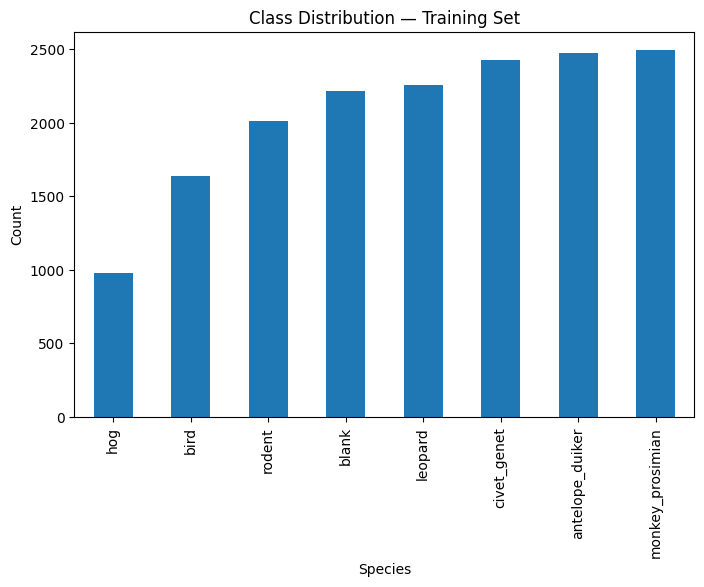

hog                  978.0
bird                1641.0
rodent              2013.0
blank               2213.0
leopard             2254.0
civet_genet         2423.0
antelope_duiker     2474.0
monkey_prosimian    2492.0
dtype: float64


In [10]:
class_counts = train_labels.sum().sort_values()
class_counts.plot(kind="bar", figsize=(8,5))
plt.xlabel("Species")
plt.ylabel("Count")
plt.title("Class Distribution — Training Set")
plt.show()

print(class_counts)

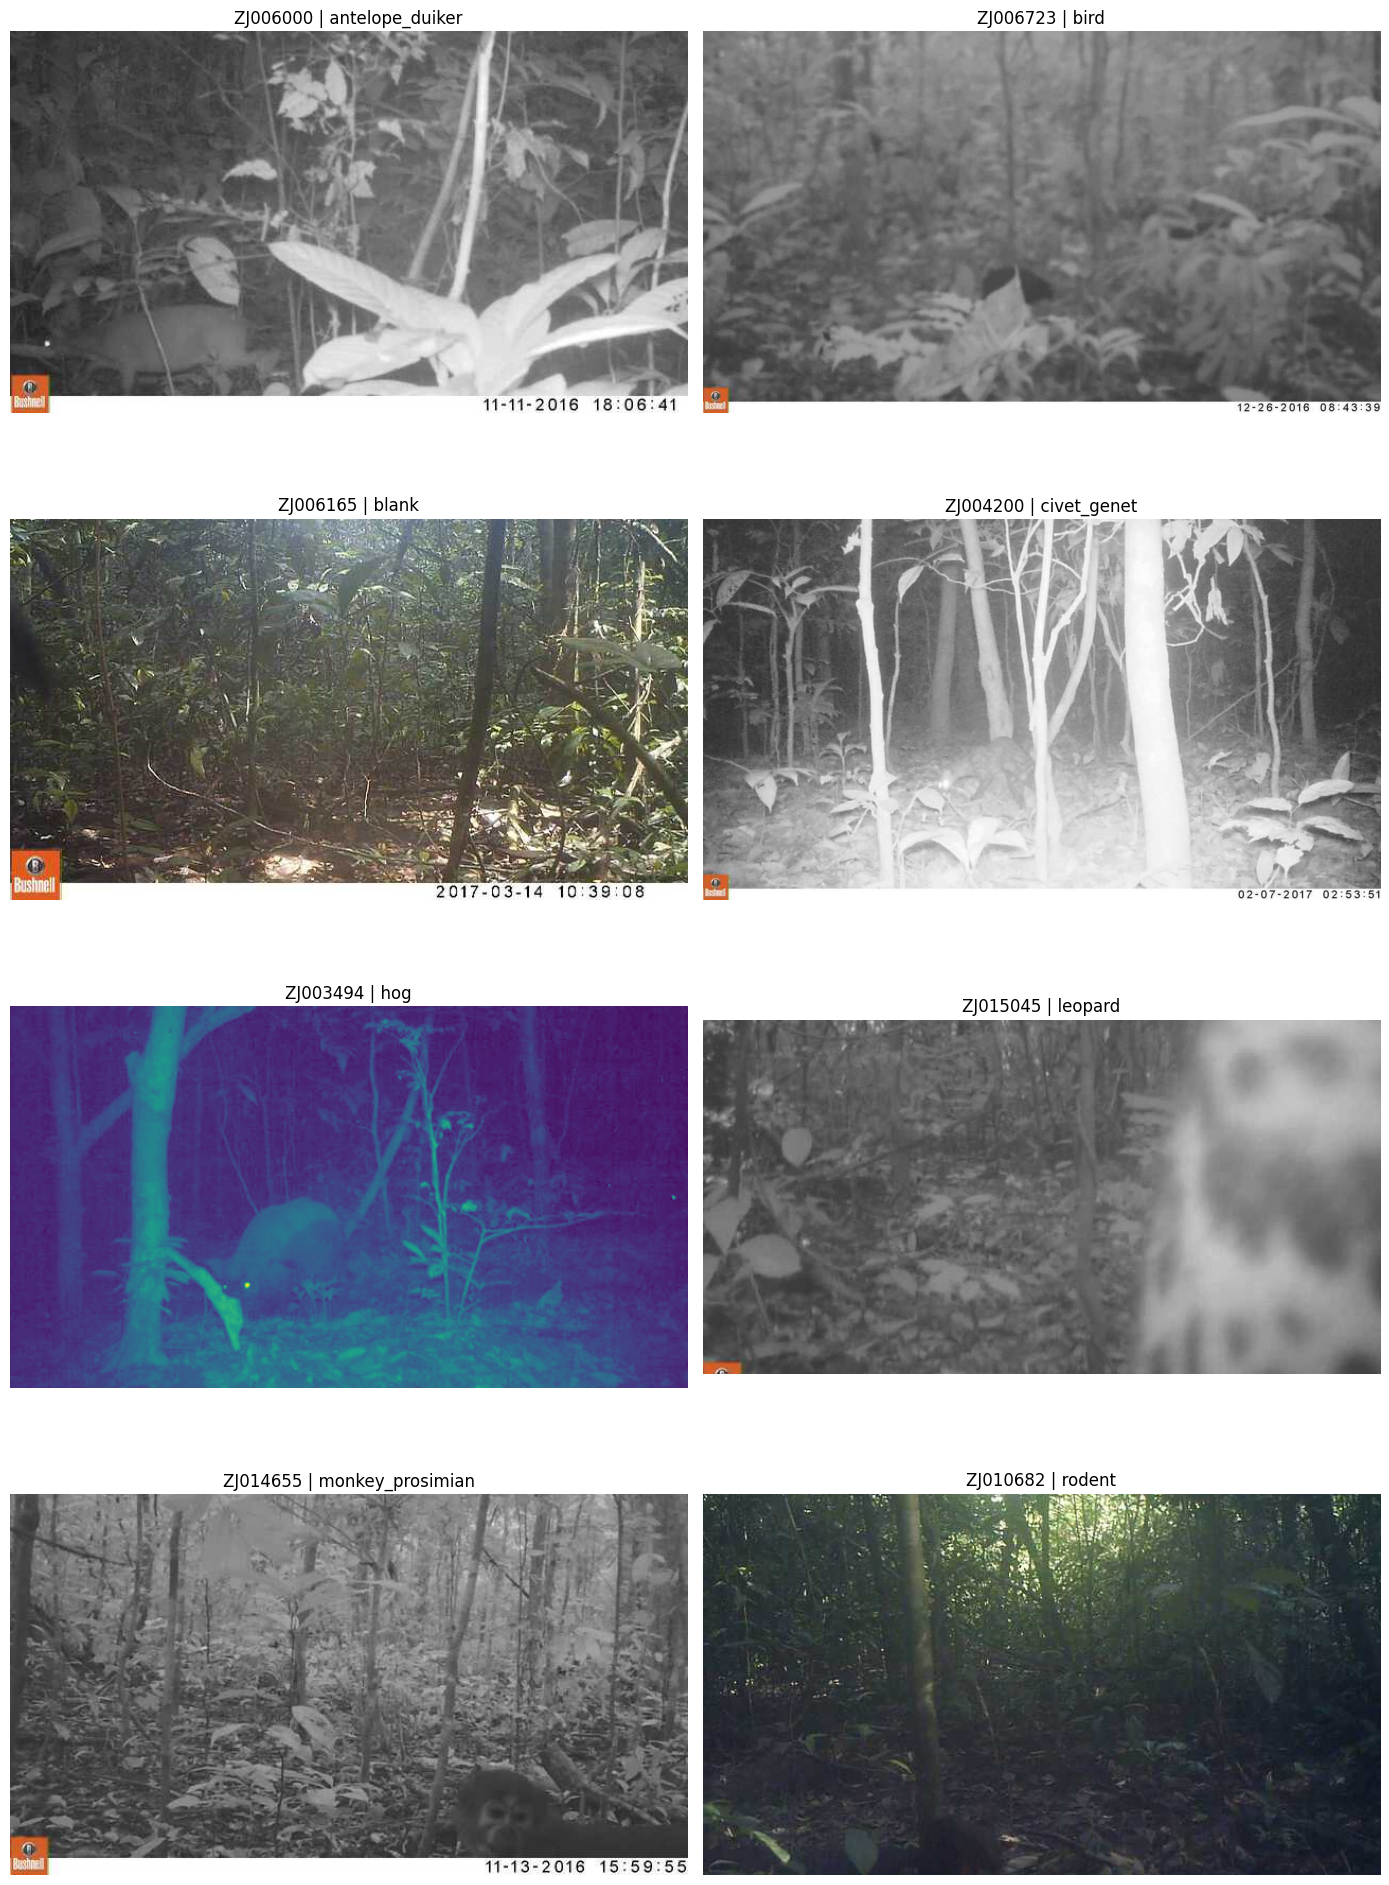

In [11]:
# Actual images per class
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 20))

for species, ax in zip(species_labels, axes.flat):
    img_id = (
        train_labels[train_labels[species] == 1]
        .sample(1, random_state=42)
        .index[0]
    )
    img_path = os.path.join(DATA_DIR, train_features.loc[img_id, "filepath"])
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(f"{img_id} | {species}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Image sizes + site distribution

Camera trap images are sometimes inconsistent in size, and site tells you how many distinct camera locations exist (images from the same site can look very similar, which affects how "independent" your train/val split really is).

In [12]:
# Check a handful of raw image sizes before we force-resize everything
sample_ids = train_features.sample(5, random_state=42).index
for img_id in sample_ids:
    img_path = os.path.join(DATA_DIR, train_features.loc[img_id, "filepath"])
    with Image.open(img_path) as img:
        print(img_id, img.size, img.mode)

print("\nNumber of distinct camera sites:", train_features["site"].nunique())

ZJ008416 (640, 360) RGB
ZJ009568 (640, 360) RGB
ZJ012401 (360, 240) RGB
ZJ011818 (960, 540) RGB
ZJ008603 (640, 360) RGB

Number of distinct camera sites: 148


In [13]:
# Custom Dataset
class ConserVisionDataset(Dataset):
    def __init__(self, features_df, labels_df, data_dir, transform=None):
        self.features_df = features_df
        self.labels_df = labels_df
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.features_df)

    def __getitem__(self, idx):
        img_id = self.features_df.index[idx]
        img_path = os.path.join(self.data_dir, self.features_df.loc[img_id, "filepath"])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(self.labels_df.loc[img_id].values.astype("float32"))
        label = torch.argmax(label)  # single-label classification: index of the 1

        return image, label

## Prepare Dataset

In [14]:
# Transforms + compute mean/std for `ConserVisionDataset` dataset
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

raw_dataset = ConserVisionDataset(train_features, train_labels, DATA_DIR, transform=basic_transform)
raw_loader = DataLoader(raw_dataset, batch_size=32)

def get_mean_std(loader):
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    for data, _ in tqdm(loader, desc="Computing mean/std"):
        channels_sum += torch.mean(data, dim=[0,2,3])
        channels_squared_sum += torch.mean(data**2, dim=[0,2,3])
        num_batches += 1
    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean**2) ** 0.5
    return mean, std

mean, std = get_mean_std(raw_loader)
print("Mean:", mean, "Std:", std)

Computing mean/std:   0%|          | 0/516 [00:00<?, ?it/s]

Mean: tensor([0.4787, 0.4925, 0.4833]) Std: tensor([0.2541, 0.2470, 0.2501])


In [15]:
# Transform, dataset, split, loaders
transform_norm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

normalized_dataset = ConserVisionDataset(train_features, train_labels, DATA_DIR, transform=transform_norm)
dataset_loader = DataLoader(normalized_dataset, batch_size=32)

norm_mean, norm_std = get_mean_std(dataset_loader)
print("Mean:", norm_mean, "Std:", norm_std)

Computing mean/std:   0%|          | 0/516 [00:00<?, ?it/s]

Mean: tensor([ 1.0156e-07, -1.2906e-07, -4.7661e-07]) Std: tensor([1.0000, 1.0000, 1.0000])


In [16]:
# Train, val split
g = torch.Generator()
g.manual_seed(42)

train_dataset, val_dataset = random_split(normalized_dataset, [0.8, 0.2], generator=g)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

print("Train size:", len(train_dataset), "Val size:", len(val_dataset))

Train size: 13191 Val size: 3297


## Build model (A simple CNN model)

In [17]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model = torch.nn.Sequential(
    torch.nn.Conv2d(3, 16, 3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(2, stride=2),

    torch.nn.Conv2d(16, 32, 3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(2, stride=2),

    torch.nn.Conv2d(32, 64, 3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(2, stride=2),

    torch.nn.Flatten(),
    torch.nn.Dropout(),
    torch.nn.Linear(64*28*28, 500),
    torch.nn.ReLU(),
    torch.nn.Dropout(),
    torch.nn.Linear(500, len(species_labels)),
)

model.to(device)
summary(model, input_size=(batch_size, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 8]                   --
├─Conv2d: 1-1                            [32, 16, 224, 224]        448
├─ReLU: 1-2                              [32, 16, 224, 224]        --
├─MaxPool2d: 1-3                         [32, 16, 112, 112]        --
├─Conv2d: 1-4                            [32, 32, 112, 112]        4,640
├─ReLU: 1-5                              [32, 32, 112, 112]        --
├─MaxPool2d: 1-6                         [32, 32, 56, 56]          --
├─Conv2d: 1-7                            [32, 64, 56, 56]          18,496
├─ReLU: 1-8                              [32, 64, 56, 56]          --
├─MaxPool2d: 1-9                         [32, 64, 28, 28]          --
├─Flatten: 1-10                          [32, 50176]               --
├─Dropout: 1-11                          [32, 50176]               --
├─Linear: 1-12                           [32, 500]                 25,088,500

## Train

In [18]:
set_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Epoch 1 train:   0%|          | 0/413 [00:00<?, ?it/s]

Epoch 1 val:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch  1/15 | train loss 1.4258 | val log loss 1.0608 | val acc 0.6248 | lr 1.00e-03 | 140s  <-- best


Epoch 2 train:   0%|          | 0/413 [00:00<?, ?it/s]

Epoch 2 val:   0%|          | 0/104 [00:00<?, ?it/s]

...

Epoch 8 val:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch  8/15 | train loss 0.3152 | val log loss 0.5007 | val acc 0.8523 | lr 1.00e-03 | 134s


Epoch 9 train:   0%|          | 0/413 [00:00<?, ?it/s]

Epoch 9 val:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch  9/15 | train loss 0.2850 | val log loss 0.5210 | val acc 0.8493 | lr 1.00e-03 | 134s
Early stopping: no improvement for 3 epochs.
Restored best weights from epoch 6 (val log loss 0.4907).


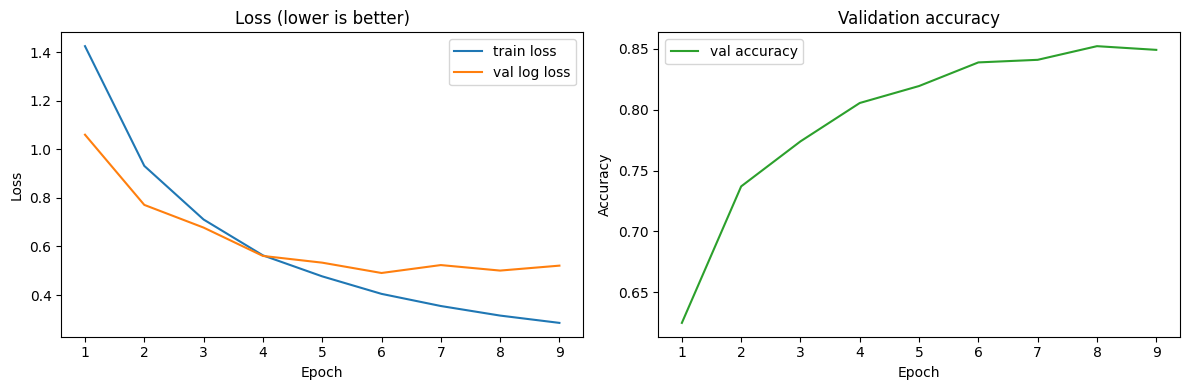

In [19]:
history = fit(
    model, train_loader, val_loader, optimizer, loss_fn,
    epochs=15, device=device,
    patience=3,
    checkpoint_path="best_baseline.pt",
    class_names=species_labels,
)
plot_history(history)

## Communicate results

In [20]:
results = evaluate(model, val_loader, device, return_outputs=True)
print(f"Val log loss: {results['log_loss']:.4f} | Val accuracy: {results['accuracy']:.4f}")

Validating:   0%|          | 0/104 [00:00<?, ?it/s]

Val log loss: 0.4907 | Val accuracy: 0.8389


## Confusion matrix (evaluation)

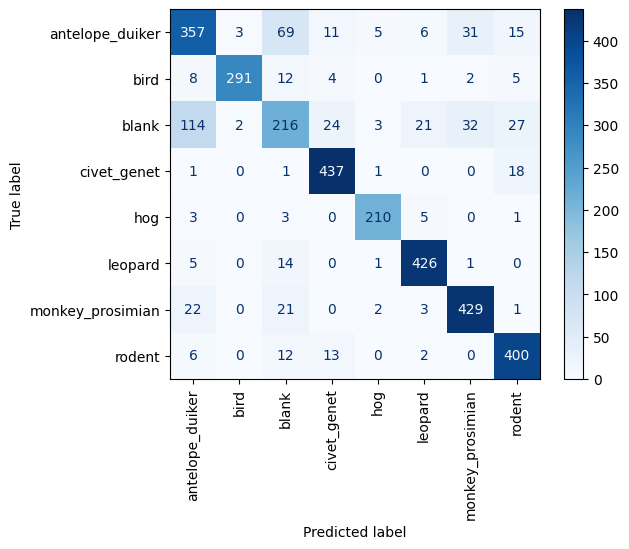

In [21]:
# Confusion Matrix
cm = confusion_matrix(results["targets"], results["probs"].argmax(axis=1))
ConfusionMatrixDisplay(cm, display_labels=species_labels).plot(
    cmap=plt.cm.Blues, xticks_rotation="vertical"
)
plt.show()

In [22]:
class ConserVisionTestDataset(Dataset):
    def __init__(self, features_df, data_dir, transform=None):
        self.features_df = features_df
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.features_df)

    def __getitem__(self, idx):
        img_id = self.features_df.index[idx]
        path = os.path.join(self.data_dir, self.features_df.loc[img_id, "filepath"])
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_id

test_dataset = ConserVisionTestDataset(test_features, DATA_DIR, transform=transform_norm)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [23]:
probs = predict_proba(model, test_loader, device)

Predicting:   0%|          | 0/70 [00:00<?, ?it/s]

In [24]:
submission_df = make_submission(
    probs, test_features.index, species_labels,
    out_path="submission.csv",
    format_path=os.path.join(DATA_DIR, "submission_format.csv"),
)

Saved submission.csv: 4464 rows x 8 columns


In [27]:
submission_df.head()

,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
id,,,,,,,,
ZJ016488,0.099931,6.885465e-08,0.055737,0.834834,3.743567e-07,0.000142,5.223157e-09,0.009356
ZJ016489,0.451803,2.978857e-02,0.212326,0.008916,1.738114e-02,0.215029,9.144092e-03,0.055613
ZJ016490,0.479547,1.959571e-04,0.111969,0.375606,5.952660e-04,0.006093,5.796415e-05,0.025935
ZJ016491,0.092437,2.559207e-04,0.697881,0.020555,1.388840e-02,0.160999,6.815427e-04,0.013302
ZJ016492,0.548568,2.968075e-02,0.391269,0.002711,2.487866e-03,0.000946,1.021319e-02,0.014124
